<a href="https://colab.research.google.com/github/BarbaraLascosck/analise-formacoes-futebol-americano/blob/main/AnaliseFormacoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
!pip install roboflow
from roboflow import Roboflow
from collections import Counter
from google.colab import files

Saving TESTE 1.jpeg to TESTE 1 (2).jpeg
loading Roboflow workspace...
loading Roboflow project...


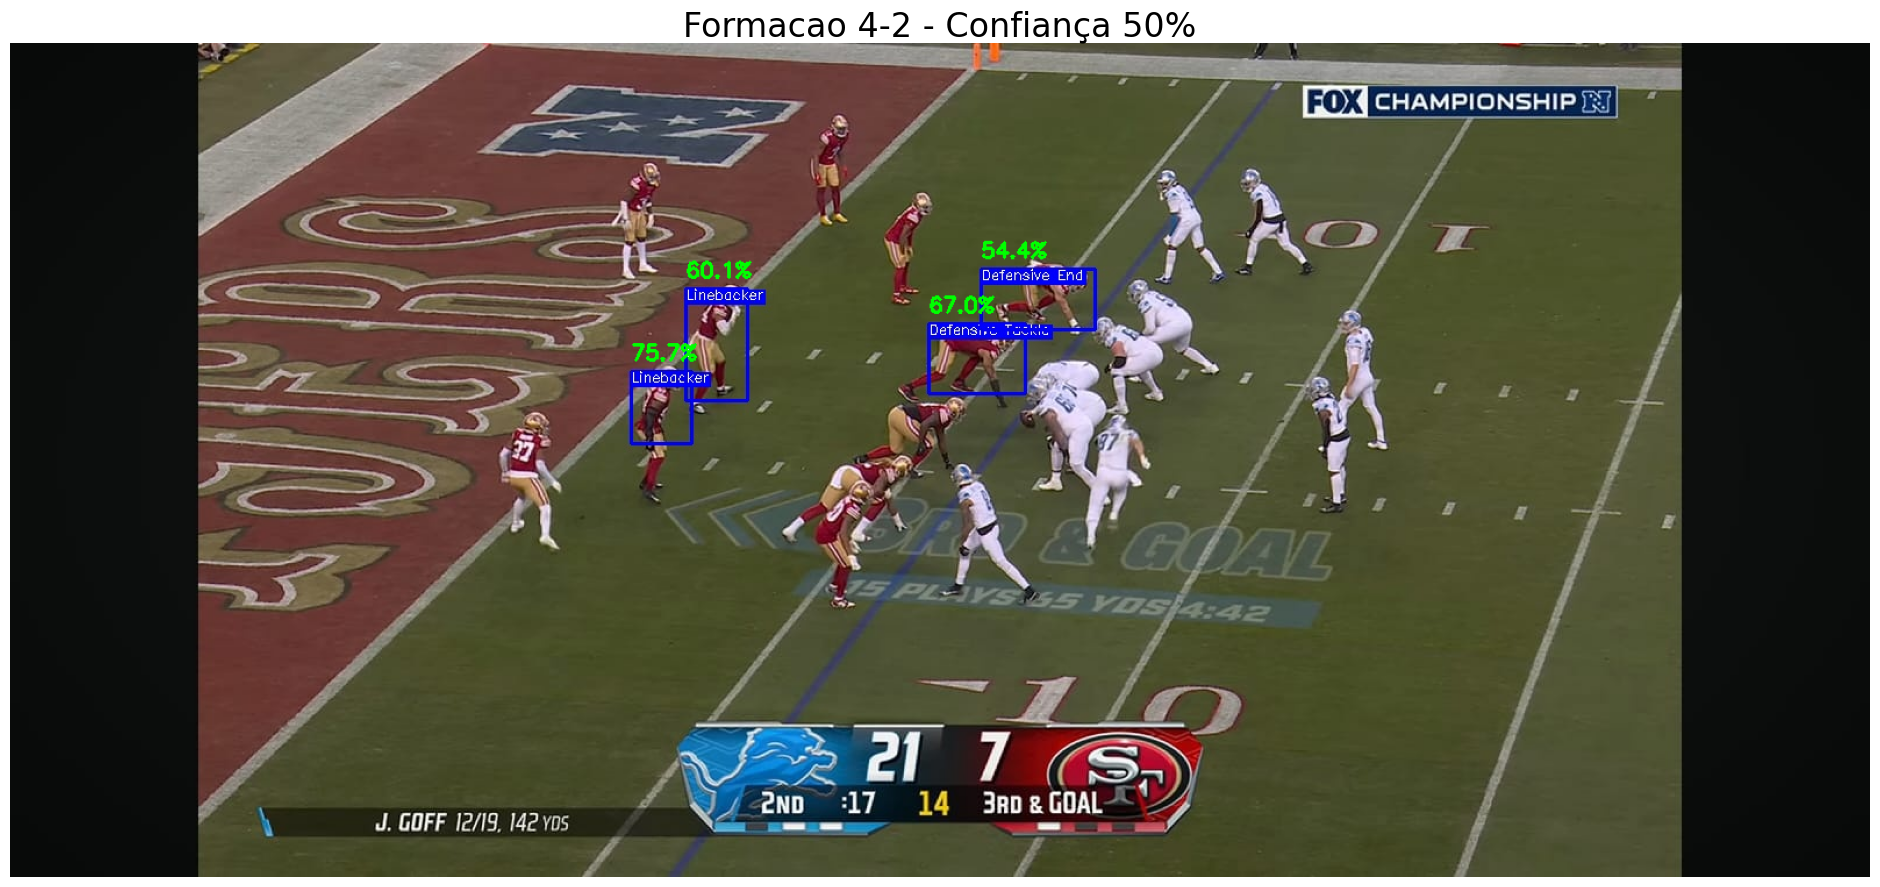

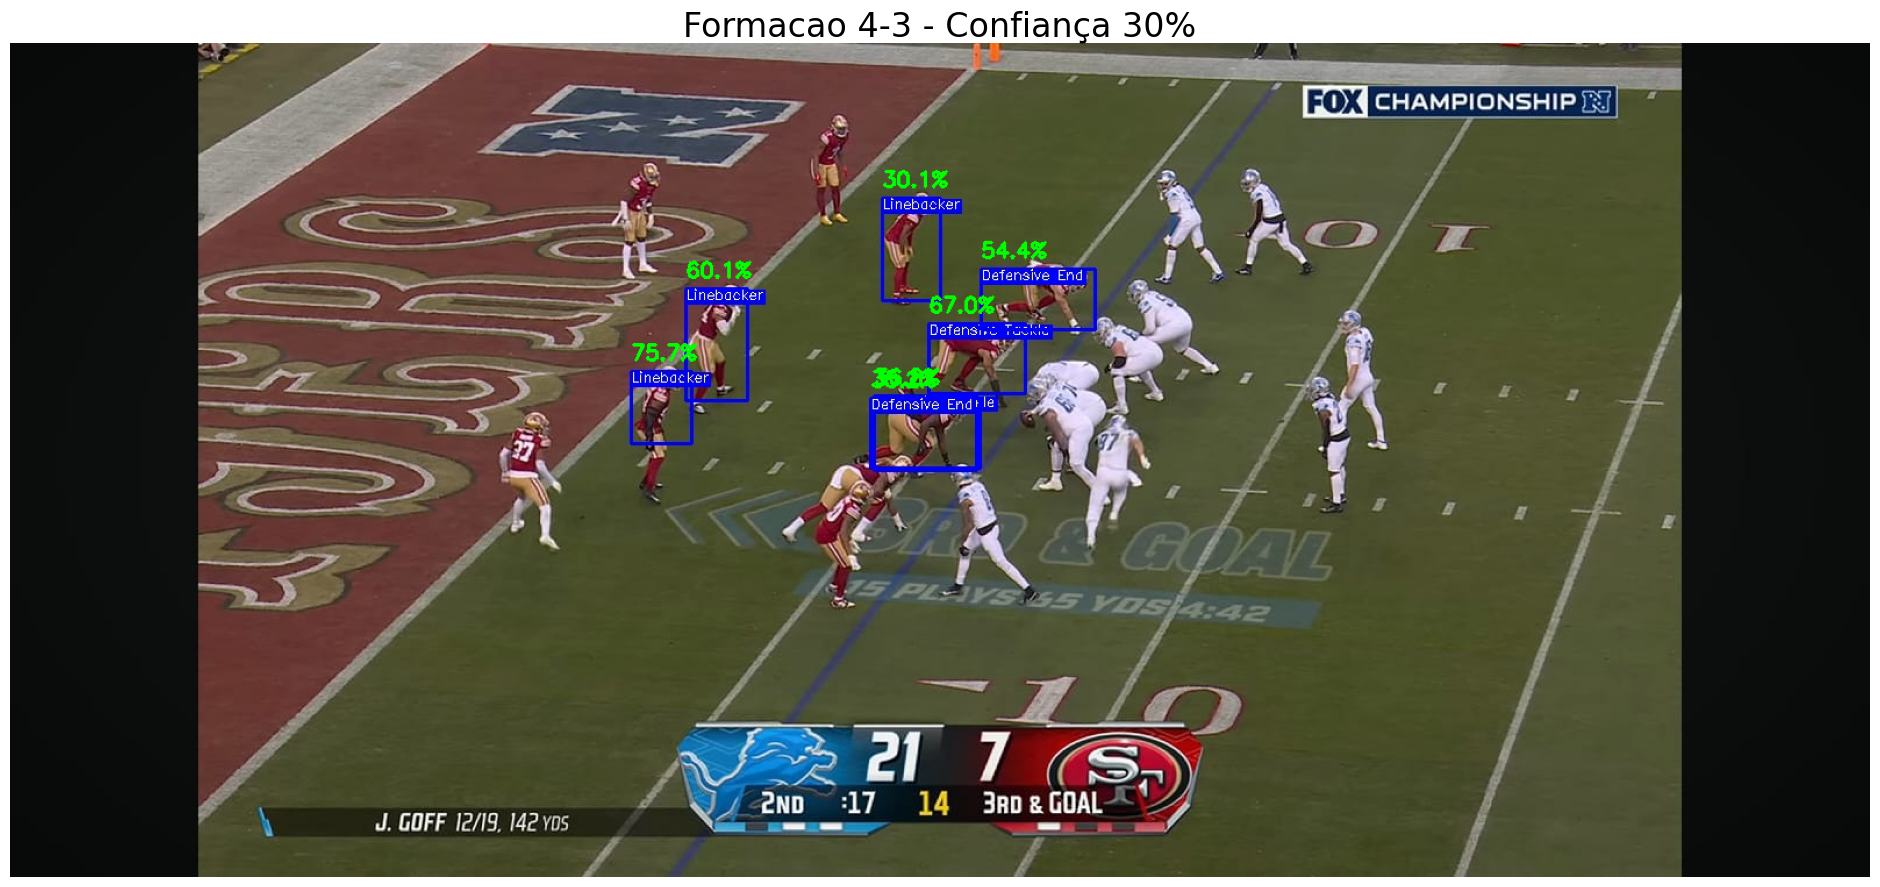

In [ ]:
# Upload das imagens
uploaded = files.upload()

# Inicializa a API
rf = Roboflow(api_key="CFKjrKlDIPgZdG0fsetM")
project = rf.workspace().project("formacoes-defensivas")
model = project.version(5).model

# Processa cada imagem com duas confiabilidades
for filename in uploaded.keys():
    for conf in (50, 30):
        # Faz a predição
        pred = model.predict(filename, confidence=conf, overlap=30)

        # Conta as classes
        labels = [p['class'] for p in pred.json()['predictions']]
        counts = Counter(labels)
        lb = counts.get('Linebacker', 0)

        # Determina a formação
        if lb == 2:
            formacao = "Formacao 4-2"
        elif lb == 3:
            formacao = "Formacao 4-3"
        else:
            formacao = "Formação indefinida"

        # Salva a imagem gerada pela predição
        out_img = f"pred_{conf}pct_" + filename
        pred.save(out_img)

        # Carrega a imagem salva
        img = cv2.imread(out_img)

        # Adiciona labels com acurácia
        for p in pred.json()['predictions']:
            x1 = int(p['x'] - p['width'] / 2)
            y1 = int(p['y'] - p['height'] / 2)
            label = f"{p['confidence']*100:.1f}%"
            cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 0), 2)

        # Mostra a imagem
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(24, 16))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"{formacao} - Confiança {conf}%", fontsize=24)
        plt.show()